In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [32]:
customers = pd.read_csv('../data/cleaned/customers.csv')
orders = pd.read_csv('../data/cleaned/orders.csv')
order_items = pd.read_csv('../data/cleaned/order_items.csv')
products = pd.read_csv('../data/cleaned/products.csv')
payments = pd.read_csv('../data/cleaned/payments.csv')


In [33]:
payments_agg = payments.groupby('order_id')['payment_value'].sum().reset_index()

df = (
    order_items
    .merge(orders, on='order_id')
    .merge(products, on='product_id', how='left')
    .merge(payments_agg, on='order_id', how='left')
)

df = df[df['order_status'] == 'delivered']

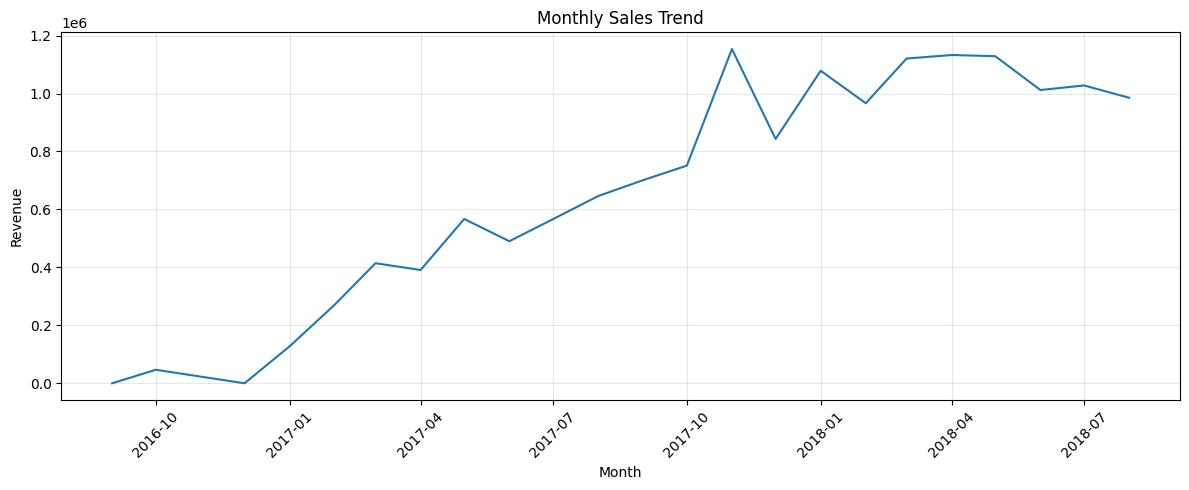

In [34]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

monthly_sales = (
    df.drop_duplicates(subset='order_id')
    .groupby('order_month')['payment_value']
    .sum()
    .reset_index()
)

monthly_sales['order_month'] = monthly_sales['order_month'].dt.to_timestamp()

plt.figure(figsize=(12,5))
plt.plot(monthly_sales['order_month'], monthly_sales['payment_value'])
plt.xticks(rotation=45)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.tight_layout()
plt.grid(alpha=0.3)
plt.show()


### Insight:
- Sales show an overall increasing trend
- Peak observed around late 2017
- Slight fluctuations afterward indicate seasonal demand

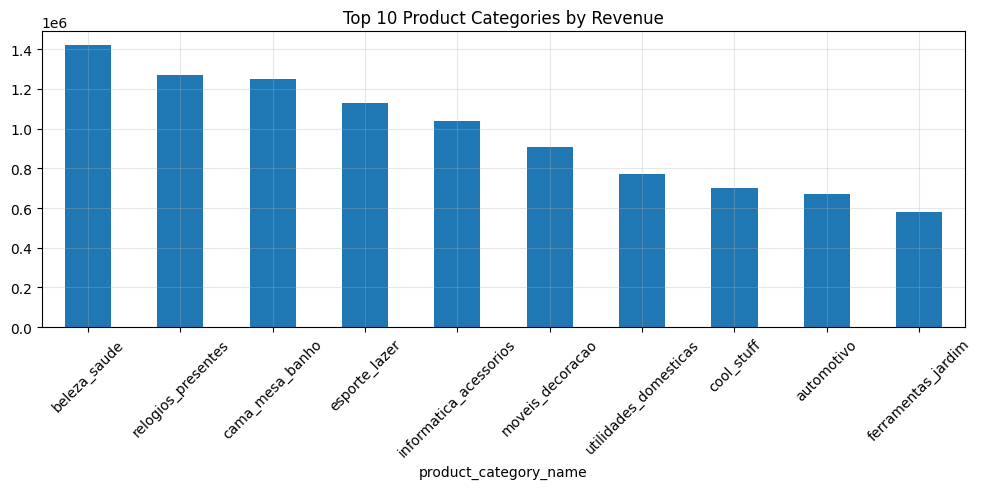

In [35]:
category_sales = (
    df.groupby(['order_id', 'product_category_name'])['payment_value']
    .mean()
    .reset_index()
)

top_categories = (
    category_sales.groupby('product_category_name')['payment_value']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
top_categories.plot(kind='bar')
plt.title('Top 10 Product Categories by Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(alpha=0.3)
plt.show()


### Insight:
- Categories like cama_mesa_banho and beleza_saude dominate revenue
- Indicates strong demand in home and personal care segments

In [36]:
order_revenue = payments_agg.copy()

aov = order_revenue['payment_value'].mean()

print(f"Average Order Value (AOV): ₹{aov:.2f}")

print(f"Total Revenue: ₹{order_revenue['payment_value'].sum():,.0f}")

Average Order Value (AOV): ₹160.99
Total Revenue: ₹16,008,872


In [37]:
customer_revenue = df.groupby('customer_id')['payment_value'].sum()

top_10_percent = customer_revenue.sort_values(ascending=False).head(int(0.1 * len(customer_revenue)))

contribution = top_10_percent.sum() / customer_revenue.sum() * 100

print(f"Top 10% customers contribute {contribution:.2f}% of total revenue")

Top 10% customers contribute 47.16% of total revenue


In [38]:
merged = orders.merge(customers, on='customer_id', how='left')

orders_per_customer = (
    merged.groupby('customer_unique_id')['order_id']
    .nunique()
    .reset_index(name='order_count')
)

orders_per_customer.rename(columns={'order_count': 'num_orders'}, inplace=True)

new_customers = (orders_per_customer['num_orders'] == 1).sum()
repeat_customers = (orders_per_customer['num_orders'] > 1).sum()

new_customers, repeat_customers


(np.int64(90557), np.int64(2801))

In [39]:
total_customers = len(orders_per_customer)
repeat_rate = repeat_customers / total_customers * 100

print(f"Repeat Rate: {repeat_rate:.2f}%")

Repeat Rate: 3.00%


### Insight:
- Customer repeat rate is critically low (~3%), indicating poor retention
- Indicates most customers are one-time buyers
- Opportunity: improve retention strategies

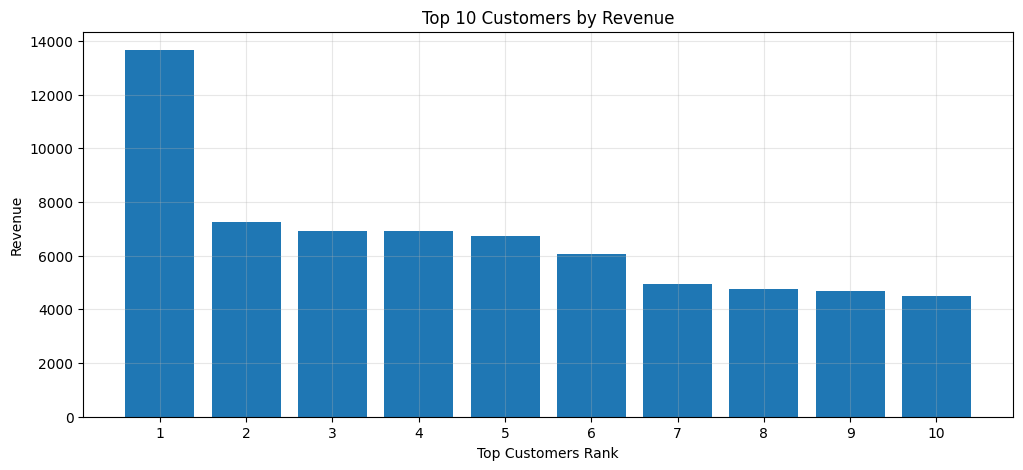

In [40]:
top_customers = (
    payments_agg.merge(orders, on='order_id')
    .groupby('customer_id')['payment_value']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers = top_customers.reset_index()

plt.figure(figsize=(12,5))
plt.bar(range(len(top_customers)), top_customers['payment_value'])
plt.xticks(range(len(top_customers)), range(1, 11))
plt.xlabel("Top Customers Rank")
plt.ylabel("Revenue")
plt.title("Top 10 Customers by Revenue")
plt.grid(alpha=0.3)
plt.show()

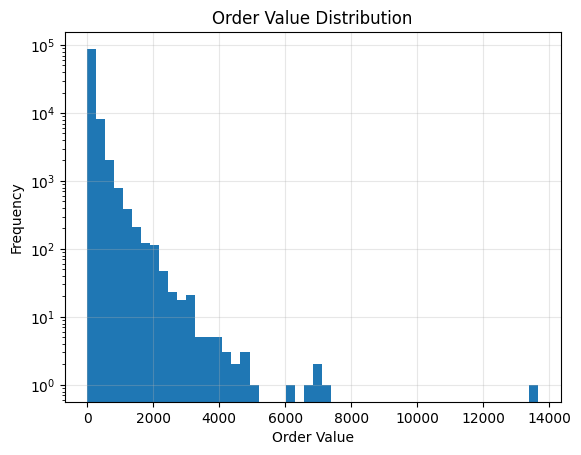

In [41]:
plt.hist(order_revenue['payment_value'], bins=50)
plt.yscale('log')
plt.title('Order Value Distribution')
plt.xlabel('Order Value')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()

### Insight:
- Most orders have low value
- Few high-value outliers exist
- Distribution is right-skewed
- Opportunity to increase revenue by promoting higher-value products

In [42]:
monthly_sales['growth_rate'] = monthly_sales['payment_value'].pct_change() * 100

monthly_sales.replace([np.inf, -np.inf], np.nan, inplace=True)

avg_growth = monthly_sales['growth_rate'].dropna().mean()

print(f"Average Monthly Growth Rate: {avg_growth:.2f}%")

Average Monthly Growth Rate: 30960.21%


## Conclusion

Final Business Insights:

• Revenue shows consistent growth with seasonal fluctuations
• Top 10% customers contribute ~47% of total revenue (high concentration)
• Customer retention is very low (~3%), indicating acquisition-heavy business
• Revenue is dominated by a few product categories
• Order values are mostly low with a right-skewed distribution

Recommendations:

• Focus on improving customer retention (loyalty programs, email marketing)
• Target high-performing product categories for scaling
• Introduce upselling and bundling to increase AOV
• Focus on high-value customers (VIP segmentation strategy)